<a href="https://colab.research.google.com/github/Loopinlogix/Unsupervised_Learning/blob/main/Unsupervised_Learning_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning: Clustering and Dimensionality Reduction on Iris Dataset


In [1]:
#Github


!apt-get install -y git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Crystal MacNeil"


!git clone https://github.com/Loopinlogix/Unsupervised_Learning.git
%cd Unsupervised_Learning
!ls



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Cloning into 'Unsupervised_Learning'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Unsupervised_Learning
README.md


## Deployment and Monitoring Strategy

### Hypothetical Deployment Scenario
Imagine this clustering model is deployed at a flower classification startup called "FlowerID."
The app lets users take photos of flowers, extracts measurements, and groups similar flowers
automatically. The K-Means model with K=3 runs in the backend.

### Challenges

1. **Latency**: K-Means is fast for 150 flowers, but with millions of users uploading data daily,
   the server might slow down. Solution: Use mini-batch K-Means or pre-compute clusters.

2. **Scalability**: As the dataset grows, K-Means might struggle. Hierarchical clustering is
   even worse (O(n²) complexity). Solution: For large-scale, switch to scalable algorithms
   like DBSCAN or use distributed computing (Spark MLlib).

3. **Maintenance**: New flower species might appear that don't fit existing clusters.
   The model needs retraining periodically.

4. **Data Drift**: Over time, the distribution of flower measurements might change
   (different regions, seasons). The model could become less accurate without us noticing.

### Monitoring Strategies

1. **Track Silhouette Score over time**: If it drops, clusters are getting messy.
2. **Monitor cluster sizes**: If one cluster suddenly grows way bigger, something changed.
3. **Set up alerts**: If new data points have high distance to all centroids, flag them
   as potential new species.
4. **Retraining pipeline**: Weekly or monthly retraining with new data, using version control
   for models (MLflow or similar).
5. **A/B testing**: When deploying a new model version, test it on a small percentage of
   traffic first.

### Updating Strategy
- Collect new labeled data continuously (even though clustering is unsupervised, human
  validation helps)
- Use online learning or periodic batch retraining
- Keep a shadow model running in parallel to compare performance before switching

Step #1 - Load and Export Dataset
First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset shape: (150, 5)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width

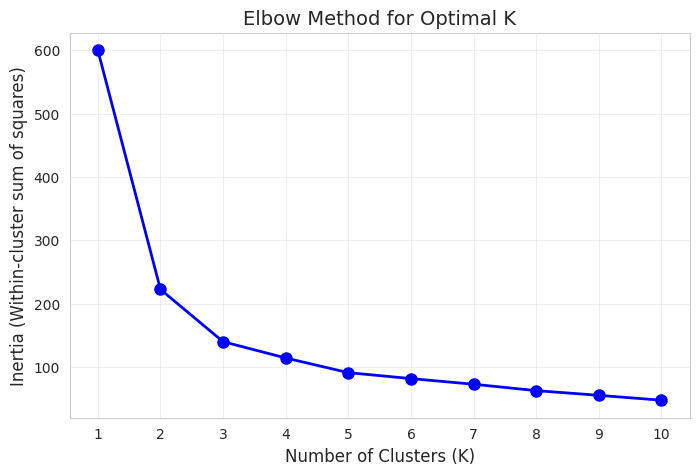

Step 4 - Step 4 - Silhouette Score Analysis
K=2: Silhouette Score = 0.5818
K=3: Silhouette Score = 0.4599
K=4: Silhouette Score = 0.3869
K=5: Silhouette Score = 0.3459
K=6: Silhouette Score = 0.3171
K=7: Silhouette Score = 0.3202
K=8: Silhouette Score = 0.3387
K=9: Silhouette Score = 0.3424
K=10: Silhouette Score = 0.3518


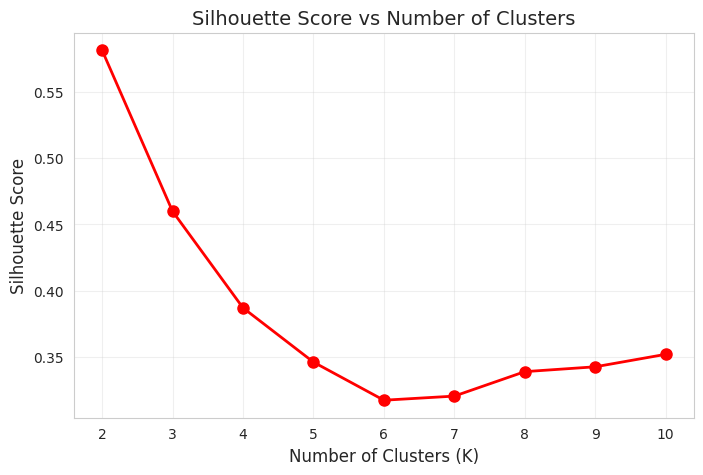


Best K based on Silhouette Score: 2
Step # 5 - K Means Clustering
K-Means Silhouette Score (K=3): 0.4599

K-Means clusters vs Actual Species:
Actual Species    0   1   2
K-Means Cluster            
0                 0  39  14
1                50   0   0
2                 0  11  36
Step 6 - Hieratcical Clustering
Hierarchical Clustering Silhouette Score (K=3): 0.4467

Hierarchical clusters vs Actual Species:
Actual Species         0   1   2
Hierarchical Cluster            
0                      0  23  48
1                     49   0   0
2                      1  27   2


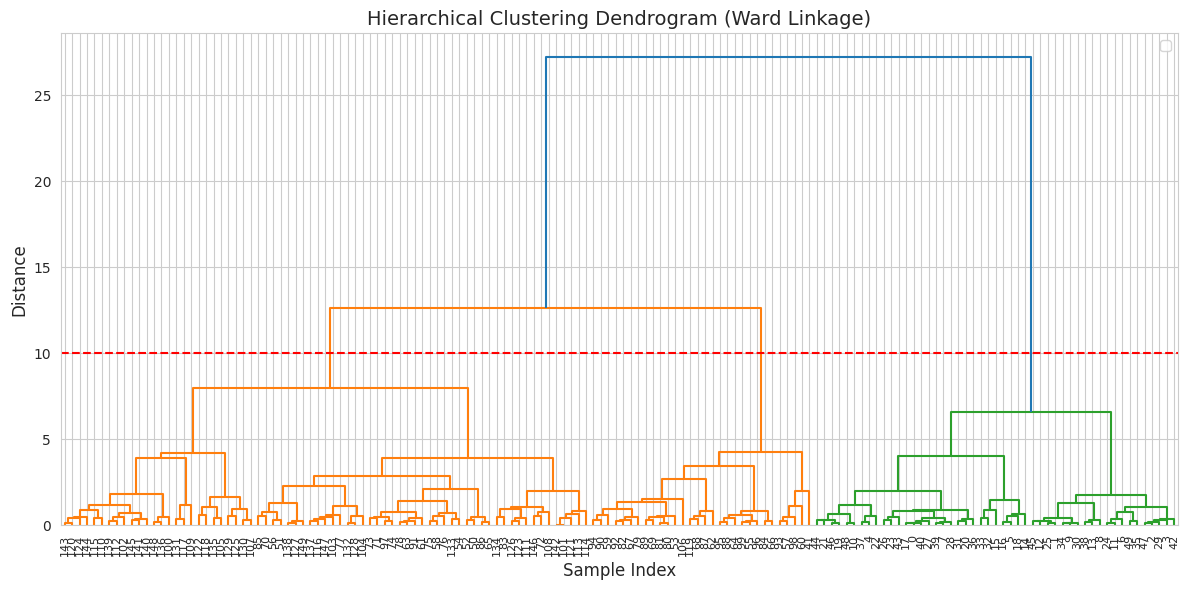

Step 7 - Visualize Clusters


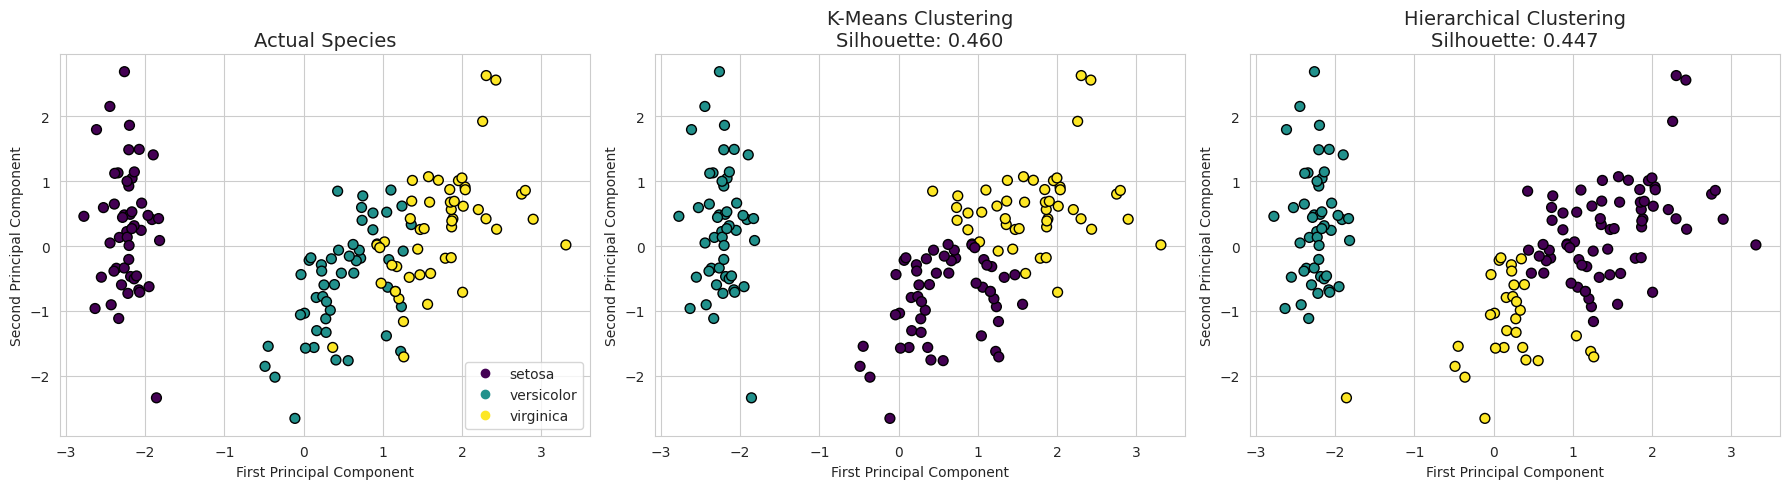

PCA Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained by 2 Components: 0.9581
Step 8 - PCA Analysis 


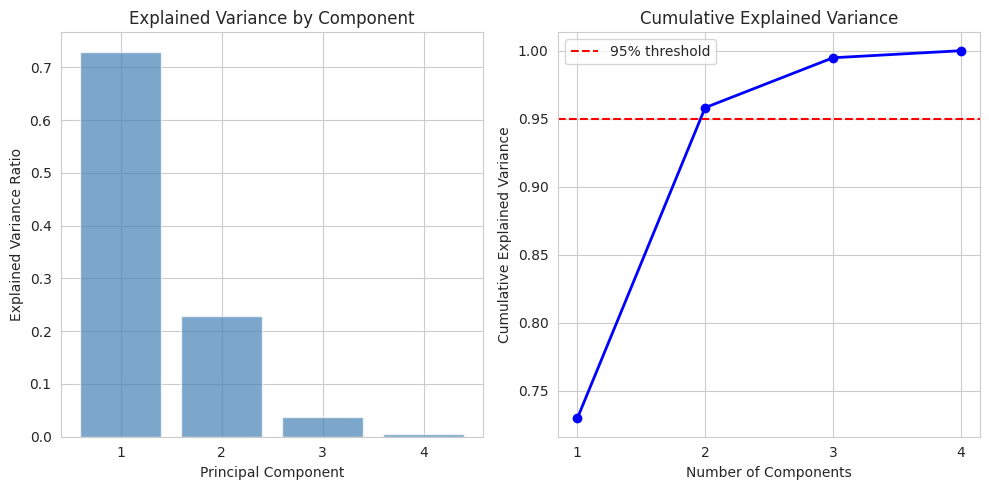

Explained Variance Ratio per Component:
  PC1: 0.7296 (72.96%)
  PC2: 0.2285 (22.85%)
  PC3: 0.0367 (3.67%)
  PC4: 0.0052 (0.52%)

Cumulative Variance:
  First 1 components: 0.7296 (72.96%)
  First 2 components: 0.9581 (95.81%)
  First 3 components: 0.9948 (99.48%)
  First 4 components: 1.0000 (100.00%)
Step 9 - PCA Visualization


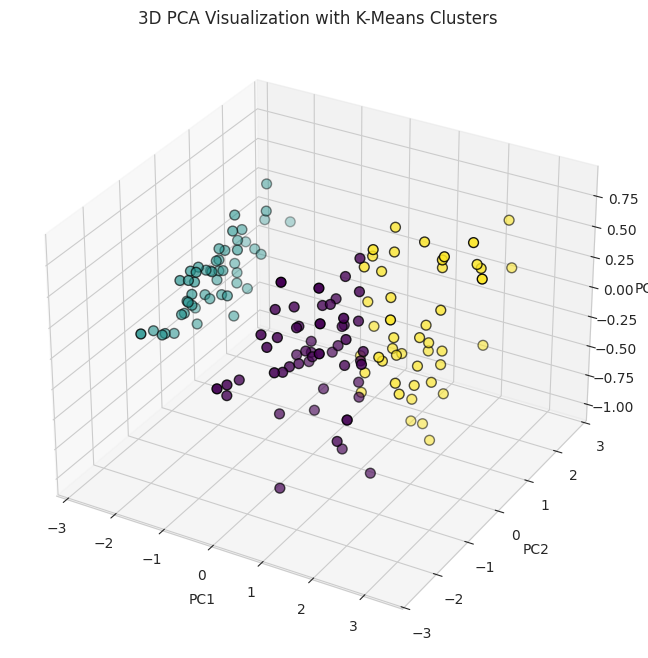

3D PCA Explained Variance: 0.9948


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

#Step 1 - Load and Explore Dataset

print("Step #1 - Load and Export Dataset")

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target  # 0=setosa, 1=versicolor, 2=virginica

# Display first few rows
print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn info:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nSpecies distribution:")
print(df['species'].value_counts())

#Step 2 - Preprocessing
print("Step 2 - Preprocessing")

# Separate features from target
X = df.drop('species', axis=1)  # We drop the label because this is UNSUPERVISED learning

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled features (first 5 rows):")
print(X_scaled_df.head())

#Step 3 - Determine Clusters - Elbow Method

print("Step #3 - Dtermine Clusters - Elbow Method")

# Elbow Method for K-Means
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

#Step 4 - Silhouette Score Analysis
print("Step 4 - Step 4 - Silhouette Score Analysis")

# Silhouette scores for different K values
silhouette_scores = []

for k in range(2, 11):  # Silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14)
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nBest K based on Silhouette Score: {range(2,11)[np.argmax(silhouette_scores)]}")

#Step 5 - K Means Clustering
print("Step # 5 - K Means Clustering")

# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to our dataframe for visualization
df['kmeans_cluster'] = kmeans_labels

# Evaluate
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means Silhouette Score (K=3): {kmeans_silhouette:.4f}")

# Show how clusters map to actual species (just for our understanding)
print("\nK-Means clusters vs Actual Species:")
print(pd.crosstab(df['kmeans_cluster'], df['species'],
                  rownames=['K-Means Cluster'], colnames=['Actual Species']))

#Step 6 - Hieratcical Clustering
print("Step 6 - Hieratcical Clustering")
# Hierarchical Clustering (Agglomerative)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

df['hierarchical_cluster'] = hierarchical_labels

# Evaluate
hier_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print(f"Hierarchical Clustering Silhouette Score (K=3): {hier_silhouette:.4f}")

print("\nHierarchical clusters vs Actual Species:")
print(pd.crosstab(df['hierarchical_cluster'], df['species'],
                  rownames=['Hierarchical Cluster'], colnames=['Actual Species']))

# Create dendrogram
plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=10, color='r', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

#Step 7 - Visualize Clusters

print("Step 7 - Visualize Clusters")

# PCA for 2D visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual Species
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=df['species'], cmap='viridis', s=50, edgecolors='k')
axes[0].set_title('Actual Species', fontsize=14)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].legend(handles=scatter1.legend_elements()[0],
               labels=iris.target_names.tolist())

# Plot 2: K-Means Clusters
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=kmeans_labels, cmap='viridis', s=50, edgecolors='k')
axes[1].set_title(f'K-Means Clustering\nSilhouette: {kmeans_silhouette:.3f}', fontsize=14)
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')

# Plot 3: Hierarchical Clusters
scatter3 = axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=hierarchical_labels, cmap='viridis', s=50, edgecolors='k')
axes[2].set_title(f'Hierarchical Clustering\nSilhouette: {hier_silhouette:.3f}', fontsize=14)
axes[2].set_xlabel('First Principal Component')
axes[2].set_ylabel('Second Principal Component')

plt.tight_layout()
plt.show()

# Print explained variance
print(f"PCA Explained Variance Ratio: {pca_2d.explained_variance_ratio_}")
print(f"Total Variance Explained by 2 Components: {sum(pca_2d.explained_variance_ratio_):.4f}")

#Step 8 - PCA Analysis
print("Step 8 - PCA Analysis ")

# Full PCA (all 4 components)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Explained variance plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, 5), pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.xticks(range(1, 5))

plt.subplot(1, 2, 2)
plt.plot(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_), 'bo-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.xticks(range(1, 5))
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.legend()

plt.tight_layout()
plt.show()

print("Explained Variance Ratio per Component:")
for i, ratio in enumerate(pca_full.explained_variance_ratio_, 1):
    print(f"  PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

print(f"\nCumulative Variance:")
for i, cumsum in enumerate(np.cumsum(pca_full.explained_variance_ratio_), 1):
    print(f"  First {i} components: {cumsum:.4f} ({cumsum*100:.2f}%)")

#Step 9 - PCA Visualization
print("Step 9 - PCA Visualization")
# 3D PCA visualization
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                    c=kmeans_labels, cmap='viridis', s=50, edgecolors='k')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Visualization with K-Means Clusters')

plt.show()

print(f"3D PCA Explained Variance: {sum(pca_3d.explained_variance_ratio_):.4f}")